In [20]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
import tensorflow as tf
import tensorflow_datasets as tfds

In [21]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [22]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']


In [23]:
class_names = [
'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro', 'Cinco', 'Seis', 'Siete',
'Ocho', 'Nueve'
]

In [24]:
num_train_examples = metadata.splits['train'].num_examples #60 mil datos train
num_test_examples = metadata.splits['test'].num_examples #10 mil datos test



In [25]:
#Normalizar: Numeros de 0 a 255, que sean de 0 a 1
def normalize(images, labels):
 images = tf.cast(images, tf.float32)
 images /= 255
 return images, labels

In [26]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)


In [27]:
#Estructura de la red
model = tf.keras.Sequential([
 tf.keras.layers.Flatten(input_shape=(28,28,1)), #Capa de entrada
 tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta
 tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta
 tf.keras.layers.Dense(10, activation=tf.nn.softmax) #para clasificacion
])

c:\Users\Leticia\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
#Función que compila el modelo
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [29]:
#Aprendizaje por lotes de 32 cada lote
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)


In [30]:
#Realizar el aprendizaje
model.fit(
train_dataset, epochs=5,
steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE)
)

Epoch 1/5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9191 - loss: 0.2733
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9643 - loss: 0.1183
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9733 - loss: 0.0899
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9796 - loss: 0.0680
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9819 - loss: 0.0577


In [ ]:
# #Evaluar nuestro modelo ya entrenado, contra el dataset de pruebas
# test_loss, test_accuracy = model.evaluate(
# test_dataset, steps=math.ceil(num_test_examples/32)
# )
# #Imprime los resultados de precisión
# print("Resultado en las pruebas: ", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9727 - loss: 0.0909
Resultado en las pruebas:  0.9726999998092651


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


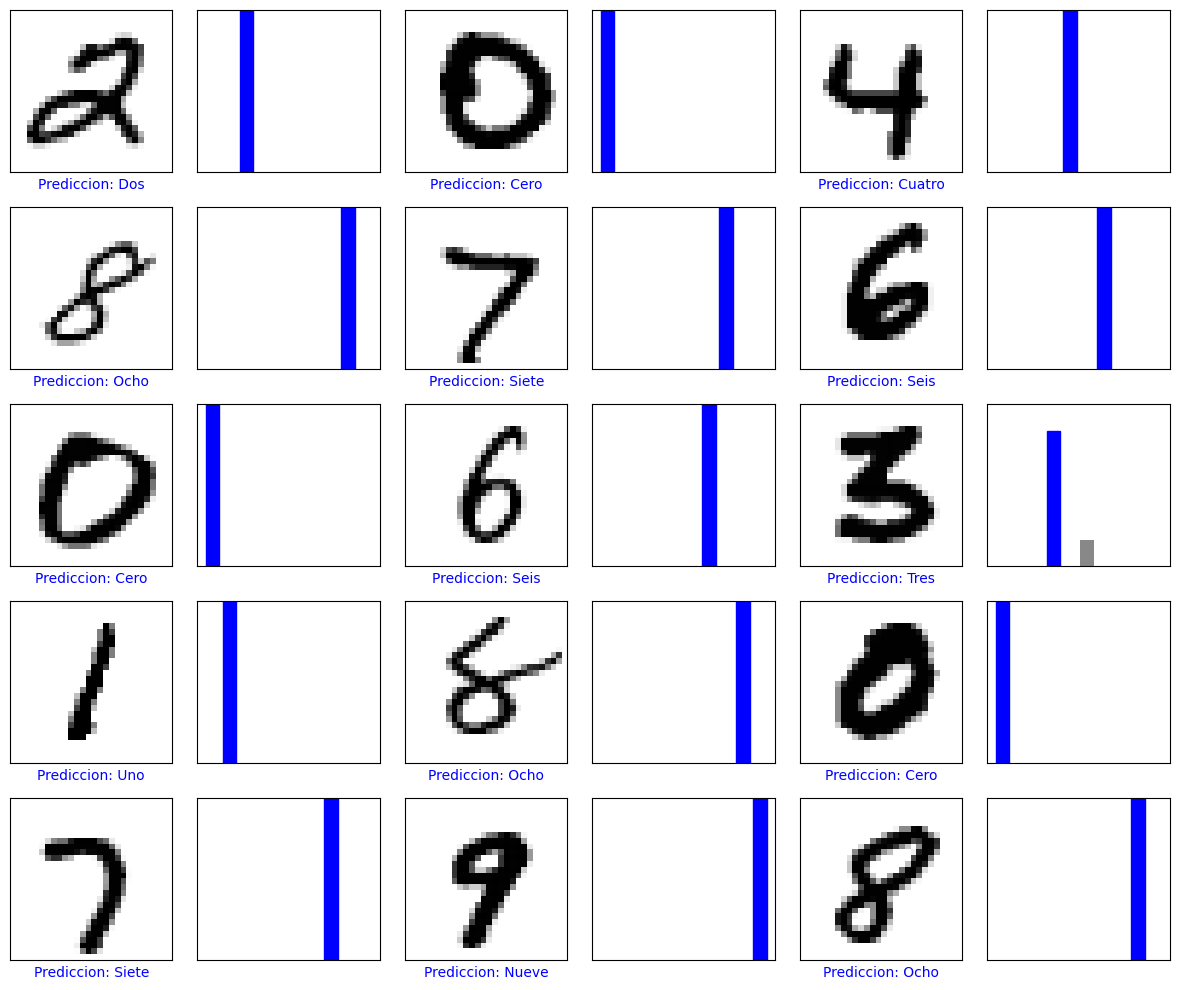

In [ ]:
# for test_images, test_labels in test_dataset.take(1):
#  test_images = test_images.numpy()
#  test_labels = test_labels.numpy()
#  predictions = model.predict(test_images)

# def plot_image(i, predictions_array, true_labels, images):
#  predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
#  plt.grid(False)
#  plt.xticks([])
#  plt.yticks([])

#  plt.imshow(img[...,0], cmap=plt.cm.binary)

#  predicted_label = np.argmax(predictions_array)
#  if predicted_label == true_label:
#   color = 'blue'
#  else:
#   color = 'red'

#  plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color)


# def plot_value_array(i, predictions_array, true_label):
#  predictions_array, true_label = predictions_array[i], true_label[i]
#  plt.grid(False)
#  plt.xticks([])
#  plt.yticks([])
#  thisplot = plt.bar(range(10), predictions_array, color="#888888")
#  plt.ylim([0,1])
#  predicted_label = np.argmax(predictions_array)

#  thisplot[predicted_label].set_color('red')
#  thisplot[true_label].set_color('blue')

# # --- AGREGA ESTO AL FINAL ---
# num_rows = 5
# num_cols = 3
# num_images = num_rows * num_cols
# plt.figure(figsize=(2*2*num_cols, 2*num_rows))
# for i in range(num_images):
#   plt.subplot(num_rows, 2*num_cols, 2*i+1)
#   plot_image(i, predictions, test_labels, test_images) # Dibuja el número
#   plt.subplot(num_rows, 2*num_cols, 2*i+2)
#   plot_value_array(i, predictions, test_labels) # Dibuja la barra
# plt.tight_layout()
# plt.show()

In [33]:
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler

In [35]:
class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        print("Peticion recibida")
        content_length = int(self.headers['Content-Length'])
        data = self.rfile.read(content_length)
        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)

        arr = np.fromstring(data, np.float32, sep=",")
        arr = arr.reshape(28, 28)
        arr = np.array(arr)
        arr = arr.reshape(1, 28, 28, 1)

        prediction_values = model.predict(arr, batch_size=1)
        prediction = str(np.argmax(prediction_values))
        print("Prediccion final: " + prediction)

        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()
        self.wfile.write(prediction.encode())

    def log_message(self, format, *args):
        pass  # Silencia los logs del servidor

print("Iniciando el servidor...")
server = HTTPServer(('localhost', 8000), SimpleHTTPRequestHandler)
server.serve_forever()

Iniciando el servidor...


: 